# Homework 1: Softmax for MNIST Classification

Build a ten-class linear classifier in NumPy. Complete the four marked `TODO` blocks, run the checks, and use your results in a short PDF report. See `HW1_Softmax_MNIST.tex` for full instructions and grading.

**Setup:** Python 3, NumPy, and Matplotlib. Keep this notebook, `mnist_data_loader.py`, and the supplied `mnist_data/` directory together in `HW1/`. The helper reads the local IDX files; running the notebook does not require internet access. Do not submit the dataset directory.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

SEED = 2026

**Newly Added Part**: 

The definition of `DATA_DIR` (Two different cases, one is for data in `data/mnist_data/` and another is for `.py` in the same dir of `mnist_data/`). 

In [2]:
import os
import sys

candidate_path = os.path.abspath(os.getcwd())

if os.path.basename(candidate_path).lower() == "codes":
    candidate_path = os.path.dirname(candidate_path)

project_code_dir = os.path.join(candidate_path, "codes")
project_data_dir = os.path.join(candidate_path, "data", "mnist_data")
original_data_dir = os.path.join(candidate_path, "mnist_data")

# Case 1:
if (
    os.path.isfile(os.path.join(project_code_dir, "mnist_data_loader.py"))
    and os.path.isdir(project_data_dir)
):
    PROJECT_ROOT = candidate_path
    CODE_DIR = project_code_dir
    DATA_DIR = project_data_dir

# Case 2:
elif (
    os.path.isfile(os.path.join(candidate_path, "mnist_data_loader.py"))
    and os.path.isdir(original_data_dir)
):
    PROJECT_ROOT = candidate_path
    CODE_DIR = candidate_path
    DATA_DIR = original_data_dir

else:
    raise FileNotFoundError(
        f"Cannot find the code and data folders in: {candidate_path}"
    )

if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

IMAGE_DIR = os.path.join(PROJECT_ROOT, "images")
REPORT_DIR = os.path.join(PROJECT_ROOT, "report")
os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

from mnist_data_loader import load_mnist

print("Project:", PROJECT_ROOT)
print("Data:", DATA_DIR)
print("Python:", sys.executable)

Project: f:\大三上-THU资料\深度学习导论\作业\Homework 1\GitHub Version
Data: f:\大三上-THU资料\深度学习导论\作业\Homework 1\GitHub Version\data\mnist_data
Python: c:\Python\Python311\python.exe


In [3]:
images_all, labels_all, images_test, labels_test = load_mnist(DATA_DIR)  # This is also a change. 
assert images_all.shape == (60_000, 28, 28) and images_test.shape == (10_000, 28, 28)
X_all = images_all.reshape(60_000, 784).astype(np.float32) / 255.0
y_all = labels_all
X_test = images_test.reshape(10_000, 784).astype(np.float32) / 255.0
y_test = labels_test

# Split the original training data; do not use the test set for training or selection.
permutation = np.random.default_rng(SEED).permutation(60_000)
train_indices, val_indices = permutation[:50_000], permutation[50_000:]
X_train, y_train = X_all[train_indices], y_all[train_indices]
X_val, y_val = X_all[val_indices], y_all[val_indices]
assert X_train.shape == (50_000, 784) and X_val.shape == (10_000, 784)
print('train / validation / test:', X_train.shape, X_val.shape, X_test.shape)

train / validation / test: (50000, 784) (10000, 784) (10000, 784)


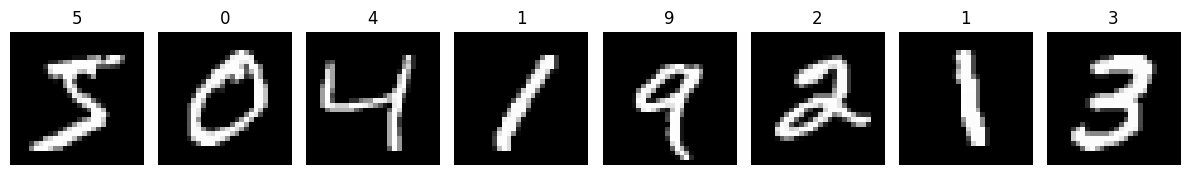

In [4]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, image, label in zip(axes, images_all[:8], labels_all[:8]):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(str(label))
    ax.axis('off')
plt.tight_layout()

# -----------------------------------------------------------------------------
# This is also a change to save the figure.
fig.savefig(
    os.path.join(IMAGE_DIR, "mnist_samples.png"), dpi=300, bbox_inches="tight"
)
# -----------------------------------------------------------------------------

plt.show()

## 1. Model and loss

For a batch $X\in\mathbb{R}^{B\times784}$, scores are $Z=XW+b$ (NumPy broadcasts $b$ across rows). Softmax gives $P_{ik}=\exp(Z_{ik}-m_i)/\sum_j\exp(Z_{ij}-m_i)$, where $m_i=\max_j Z_{ij}$. Minimize

$$L=-\frac{1}{B}\sum_i\log P_{i,y_i}+\frac{\lambda}{2}\lVert W\rVert_F^2.$$

Regularize $W$, not $b$. In the report, derive both gradients and explain why subtracting the row maximum helps. In code, obtain log probabilities from shifted scores and `log(sum(exp(shifted)))`; directly taking `log(probability)` can yield `log(0)` for extreme scores.

In [5]:
def stable_softmax(logits):
    """Return row-wise probabilities; logits has shape (B, C)."""
    # TODO 1: Subtract each row maximum, exponentiate, and normalize each row.
    # Use broadcasting; no loops over examples or classes.
    shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_shifted = np.exp(shifted_logits)
    return exp_shifted / np.sum(exp_shifted, axis=1, keepdims=True)


In [6]:
def softmax_loss_and_grad(X, y, W, b, reg):
    """Return scalar loss, dW, db for a nonempty batch.

    X: (B, D), y: (B,), W: (D, C), b: (C,).
    L2 penalty: 0.5 * reg * sum(W ** 2). Do not penalize b.
    """
    batch_size = X.shape[0]
    if batch_size == 0:
        raise ValueError('The batch must be nonempty')
    scores = X @ W + b
    probabilities = stable_softmax(scores)
    # TODO 2: Compute stable mean negative log-likelihood plus L2 penalty;
    # derive dW and db using a (B, C) probabilities-minus-one-hot matrix.
    # Do not modify probabilities in place if you need them later.
    shifted_logits = scores - np.max(scores, axis=1, keepdims=True)
    log_probs = shifted_logits - np.log(np.sum(np.exp(shifted_logits), axis=1, keepdims=True))
    data_loss = -np.mean(log_probs[np.arange(batch_size), y])
    loss = data_loss + 0.5 * reg * np.sum(W ** 2)

    error = probabilities.copy()
    error[np.arange(batch_size), y] -= 1
    error /= batch_size

    dW = X.T @ error + reg * W
    db = np.sum(error, axis=0)

    return float(loss), dW, db

In [7]:
def predict(X, W, b):
    """Return one predicted integer label per row of X."""
    # TODO 3: Compute scores and select the class with the largest score.
    scores = X @ W + b
    return np.argmax(scores, axis=1)

def accuracy(X, y, W, b):
    return float(np.mean(predict(X, W, b) == y))

## 2. Check your implementation

Run this cell after completing TODO 1–3. It tests extreme logits and checks your gradients against finite differences on a small synthetic batch. Loops in this diagnostic checker are allowed; the classifier itself must be vectorized.

In [8]:
extreme_logits = np.array([[1000., 999., -1000.], [-1000., 0., 1000.]])
p_extreme = stable_softmax(extreme_logits)
assert np.isfinite(p_extreme).all() and np.all(p_extreme >= 0)
assert np.allclose(p_extreme.sum(axis=1), 1.0)
extreme_loss, _, _ = softmax_loss_and_grad(
    np.array([[1000.]]), np.array([1]),
    np.array([[1., -1., 0.]]), np.zeros(3), 0.0)
assert np.isfinite(extreme_loss) and extreme_loss > 1000

check_rng = np.random.default_rng(7)
X_check = check_rng.normal(size=(5, 4))
y_check = np.array([0, 2, 1, 2, 0])
W_check = check_rng.normal(scale=0.1, size=(4, 3))
b_check = check_rng.normal(scale=0.1, size=3)
reg_check = 0.03
loss_check, dW_check, db_check = softmax_loss_and_grad(
    X_check, y_check, W_check, b_check, reg_check)
assert np.isfinite(loss_check)
assert dW_check.shape == W_check.shape and db_check.shape == b_check.shape
assert np.array_equal(predict(X_check, W_check, b_check),
                      np.argmax(X_check @ W_check + b_check, axis=1))

step = 1e-5
numeric_dW = np.zeros_like(W_check)
for index in np.ndindex(W_check.shape):
    W_plus, W_minus = W_check.copy(), W_check.copy()
    W_plus[index] += step
    W_minus[index] -= step
    plus = softmax_loss_and_grad(X_check, y_check, W_plus, b_check, reg_check)[0]
    minus = softmax_loss_and_grad(X_check, y_check, W_minus, b_check, reg_check)[0]
    numeric_dW[index] = (plus - minus) / (2 * step)

numeric_db = np.zeros_like(b_check)
for index in np.ndindex(b_check.shape):
    b_plus, b_minus = b_check.copy(), b_check.copy()
    b_plus[index] += step
    b_minus[index] -= step
    plus = softmax_loss_and_grad(X_check, y_check, W_check, b_plus, reg_check)[0]
    minus = softmax_loss_and_grad(X_check, y_check, W_check, b_minus, reg_check)[0]
    numeric_db[index] = (plus - minus) / (2 * step)

print('Largest absolute gradient errors:',
      np.max(np.abs(dW_check - numeric_dW)), np.max(np.abs(db_check - numeric_db)))
assert np.allclose(dW_check, numeric_dW, atol=1e-6, rtol=1e-5)
assert np.allclose(db_check, numeric_db, atol=1e-6, rtol=1e-5)
print('All checks passed.')

Largest absolute gradient errors: 1.4417994576021442e-11 1.5758033766744006e-11
All checks passed.


## 3. Mini-batch training

Only the epoch and batch loops are supplied. Use each batch's gradients to update the current parameters. Validation images must never enter a parameter update. The history records full training loss and training/validation accuracy after each epoch.

In [9]:
def train_softmax(X_train, y_train, X_val, y_val, *, learning_rate, reg,
                  epochs=8, batch_size=256, seed=SEED):
    rng = np.random.default_rng(seed)
    W = np.zeros((X_train.shape[1], 10), dtype=np.float32)
    b = np.zeros(10, dtype=np.float32)
    history = {'train_loss': [], 'train_accuracy': [], 'val_accuracy': []}
    for epoch in range(epochs):
        order = rng.permutation(len(X_train))
        for start in range(0, len(order), batch_size):
            batch_indices = order[start:start + batch_size]
            X_batch, y_batch = X_train[batch_indices], y_train[batch_indices]
            _, dW, db = softmax_loss_and_grad(X_batch, y_batch, W, b, reg)
            # TODO 4: Update W and b using learning_rate and dW/db.
            # Both gradients above used the same old parameters.
            W = W - learning_rate * dW
            b = b - learning_rate * db
        train_loss = softmax_loss_and_grad(X_train, y_train, W, b, reg)[0]
        train_acc = accuracy(X_train, y_train, W, b)
        val_acc = accuracy(X_val, y_val, W, b)
        history['train_loss'].append(float(train_loss))
        history['train_accuracy'].append(train_acc)
        history['val_accuracy'].append(val_acc)
        print(f'epoch {epoch + 1:2d}/{epochs}: loss={train_loss:.4f}, '
              f'train acc={train_acc:.4f}, val acc={val_acc:.4f}')
    return W, b, history

## 4. Compare hyperparameters

The settings below compare two learning rates with fixed regularization and two regularization values with fixed learning rate. You may modify them. Select a model using **validation accuracy only**; do not look at the test set here.

In [10]:
configs = [
    {'name': 'baseline', 'learning_rate': 0.10, 'reg': 1e-4},
    {'name': 'smaller learning rate', 'learning_rate': 0.03, 'reg': 1e-4},
    {'name': 'stronger regularization', 'learning_rate': 0.10, 'reg': 1e-2},
]
runs = {}
for config in configs:
    print('\nConfiguration:', config['name'])
    W, b, history = train_softmax(
        X_train, y_train, X_val, y_val,
        learning_rate=config['learning_rate'], reg=config['reg'],
        epochs=8, batch_size=256, seed=SEED)
    runs[config['name']] = {'config': config, 'W': W, 'b': b, 'history': history}

print('\nResults (copy to your report):')
print(f"{'configuration':26s} {'lr':>8s} {'lambda':>10s} {'train acc':>12s} {'val acc':>10s}")
for name, run in runs.items():
    cfg, h = run['config'], run['history']
    print(f"{name:26s} {cfg['learning_rate']:8.3g} {cfg['reg']:10.3g} "
          f"{h['train_accuracy'][-1]:12.4f} {h['val_accuracy'][-1]:10.4f}")
best_name = max(runs, key=lambda name: runs[name]['history']['val_accuracy'][-1])
print('Selected by final validation accuracy:', best_name)


Configuration: baseline
epoch  1/8: loss=0.4928, train acc=0.8761, val acc=0.8733
epoch  2/8: loss=0.4154, train acc=0.8907, val acc=0.8869
epoch  3/8: loss=0.3828, train acc=0.8969, val acc=0.8934
epoch  4/8: loss=0.3628, train acc=0.9015, val acc=0.8987
epoch  5/8: loss=0.3502, train acc=0.9036, val acc=0.8999
epoch  6/8: loss=0.3413, train acc=0.9068, val acc=0.9017
epoch  7/8: loss=0.3329, train acc=0.9088, val acc=0.9036
epoch  8/8: loss=0.3278, train acc=0.9106, val acc=0.9056

Configuration: smaller learning rate
epoch  1/8: loss=0.7460, train acc=0.8454, val acc=0.8418
epoch  2/8: loss=0.5764, train acc=0.8663, val acc=0.8628
epoch  3/8: loss=0.5078, train acc=0.8749, val acc=0.8718
epoch  4/8: loss=0.4687, train acc=0.8814, val acc=0.8779
epoch  5/8: loss=0.4432, train acc=0.8849, val acc=0.8812
epoch  6/8: loss=0.4246, train acc=0.8890, val acc=0.8863
epoch  7/8: loss=0.4103, train acc=0.8919, val acc=0.8881
epoch  8/8: loss=0.3992, train acc=0.8941, val acc=0.8912

Configur

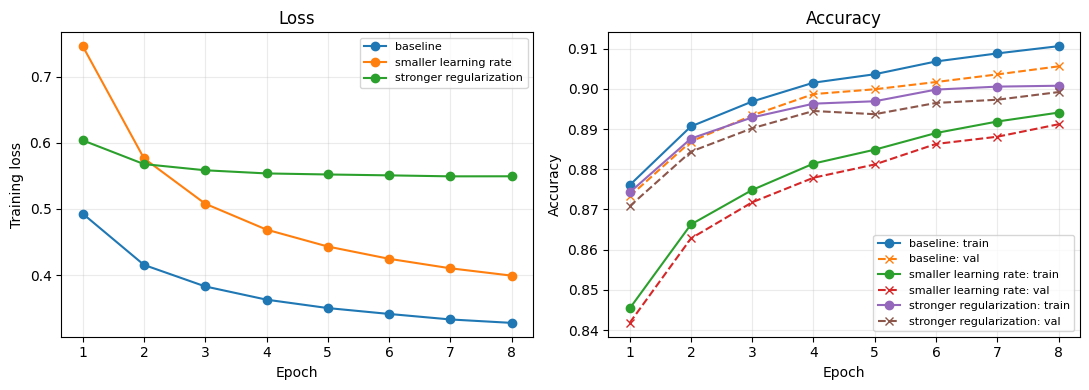

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, run in runs.items():
    h = run['history']
    epoch_axis = np.arange(1, len(h['train_loss']) + 1)
    axes[0].plot(epoch_axis, h['train_loss'], marker='o', label=name)
    axes[1].plot(epoch_axis, h['train_accuracy'], marker='o', label=f'{name}: train')
    axes[1].plot(epoch_axis, h['val_accuracy'], marker='x', linestyle='--',
                 label=f'{name}: val')
axes[0].set(xlabel='Epoch', ylabel='Training loss', title='Loss')
axes[1].set(xlabel='Epoch', ylabel='Accuracy', title='Accuracy')
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
plt.tight_layout()
# -----------------------------------------------------------------------------
# This is also a change to save the figure.
fig.savefig(
    os.path.join(IMAGE_DIR, "learning_curves.png"), dpi=300, bbox_inches="tight"
)
# -----------------------------------------------------------------------------
plt.show()

## 5. Final test evaluation

Run this cell once after selecting the configuration above. Do not change the settings based on the test result.

In [12]:
best_run = runs[best_name]
test_accuracy = accuracy(X_test, y_test, best_run['W'], best_run['b'])
print(f'Selected configuration: {best_name}')
print(f"Final validation accuracy: {best_run['history']['val_accuracy'][-1]:.4f}")
print(f'Test accuracy: {test_accuracy:.4f}')

Selected configuration: baseline
Final validation accuracy: 0.9056
Test accuracy: 0.9143


**Newly Added Part**: 

Save the training result into `.json` and `.csv`. 
Assisted by AI.

In [13]:
# Save the results already in memory; do not train or evaluate again.
import csv
import json
import platform
import matplotlib
from datetime import datetime, timezone
from importlib.metadata import PackageNotFoundError, version

os.makedirs(REPORT_DIR, exist_ok=True)
csv_path = os.path.join(REPORT_DIR, "results.csv")
json_path = os.path.join(REPORT_DIR, "experiment_record.json")

# This matches the current training call: epochs=8, batch_size=256.
# Epoch counts below are read from each actual history.
# Update this value if the training batch size is changed in a future experiment.
experiment_batch_size = 256

rows = []
run_records = {}

for name, run in runs.items():
    config = run["config"]
    history = run["history"]
    epoch_count = len(history["train_loss"])
    if epoch_count == 0:
        raise ValueError(f"No training history for: {name}")
    if not (
        len(history["train_accuracy"]) == epoch_count
        and len(history["val_accuracy"]) == epoch_count
    ):
        raise ValueError(f"History lengths do not match for: {name}")

    row = {
        "configuration": name,
        "learning_rate": float(config["learning_rate"]),
        "lambda": float(config["reg"]),
        "epochs": epoch_count,
        "batch_size": experiment_batch_size,
        "final_train_loss": float(history["train_loss"][-1]),
        "final_train_accuracy": float(history["train_accuracy"][-1]),
        "final_val_accuracy": float(history["val_accuracy"][-1]),
        "selected": name == best_name,
        # Only the selected model has a test result; other rows remain blank.
        "test_accuracy": float(test_accuracy) if name == best_name else "",
    }
    rows.append(row)
    run_records[name] = {
        "configuration": {
            "learning_rate": row["learning_rate"],
            "lambda": row["lambda"],
            "epochs": epoch_count,
            "batch_size": experiment_batch_size,
        },
        "final_train_loss": row["final_train_loss"],
        "final_train_accuracy": row["final_train_accuracy"],
        "final_val_accuracy": row["final_val_accuracy"],
        "history": {
            "train_loss": [float(value) for value in history["train_loss"]],
            "train_accuracy": [float(value) for value in history["train_accuracy"]],
            "val_accuracy": [float(value) for value in history["val_accuracy"]],
        },
    }

if not rows or best_name not in run_records:
    raise ValueError("Run the training, selection, and final evaluation cells first.")

try:
    ipykernel_version = version("ipykernel")
except PackageNotFoundError:
    ipykernel_version = None

record = {
    # This is the export time, not the training start or end time.
    "exported_at_utc": datetime.now(timezone.utc).isoformat(),
    "seed": int(SEED),
    "split_sizes": {
        "training": int(len(X_train)),
        "validation": int(len(X_val)),
        "test": int(len(X_test)),
    },
    "preprocessing": {
        "features_per_image": int(X_train.shape[1]),
        "pixel_scaling": "divide by 255.0",
        "input_dtype": str(X_train.dtype),
    },
    "parameter_initialization": "zero weights and zero biases",
    "selection_rule": (
        "highest final validation accuracy; first configured run wins ties"
    ),
    "selected_configuration": best_name,
    "selected_validation_accuracy": run_records[best_name]["final_val_accuracy"],
    "test_accuracy": float(test_accuracy),
    # These are the environment versions at export time.
    "environment_at_export": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "matplotlib": matplotlib.__version__,
        "ipykernel": ipykernel_version,
    },
    "runs": run_records,
}

# Reject NaN/Infinity before writing an invalid JSON record.
json_text = json.dumps(record, indent=2, ensure_ascii=False, allow_nan=False)

with open(csv_path, "w", newline="", encoding="utf-8-sig") as file:
    writer = csv.DictWriter(file, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

with open(json_path, "w", encoding="utf-8") as file:
    file.write(json_text)
    file.write("\n")

print("CSV saved to:", os.path.abspath(csv_path))
print("JSON saved to:", os.path.abspath(json_path))

CSV saved to: f:\大三上-THU资料\深度学习导论\作业\Homework 1\GitHub Version\report\results.csv
JSON saved to: f:\大三上-THU资料\深度学习导论\作业\Homework 1\GitHub Version\report\experiment_record.json


## Report checklist

- Derive both gradients, give their shapes, and explain the stability trick.
- Include the results table, training loss curve, and training/validation accuracy curves.
- Compare learning rate and regularization, discuss fit and a limitation of this linear classifier.
- State the selected configuration and its one-time test accuracy. Submit this executed notebook, `mnist_data_loader.py`, and your PDF report. Do not submit `mnist_data/`.